In [ ]:
from google.colab import files
uploaded = files.upload()

Saving housing.csv to housing.csv


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [ ]:
df = pd.read_csv("housing.csv")

In [ ]:
df.shape

(20640, 9)

In [ ]:
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


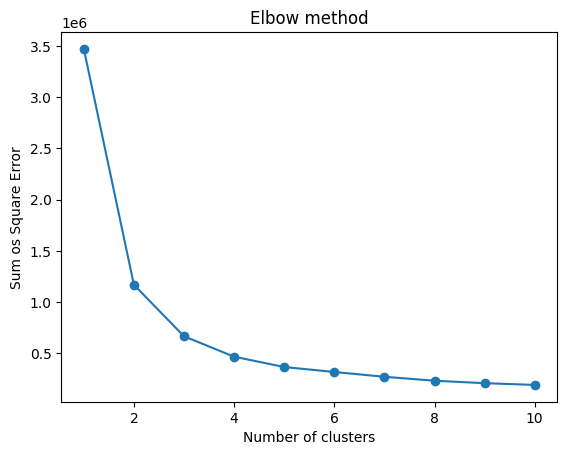

In [ ]:
from sklearn.cluster import KMeans

data = list(zip(df.MedInc, df.HouseAge, df.AveRooms))
inertias = []

for i in range(1,11):
    kmeans = KMeans(n_clusters=i, n_init='auto')
    kmeans.fit(data)
    inertias.append(kmeans.inertia_)

plt.plot(range(1,11), inertias, marker='o')
plt.title('Elbow method')
plt.xlabel('Number of clusters')
plt.ylabel('Sum os Square Error')
plt.show()

When there is no proper elbow then we use feature extraction technique, where in be reduce the number of attributes without actually removing any of the original attributes. For example if there are 3 attributes then we will reduce it down to 2 attributes by taking the normals or averaging all the three attributes.

Here we will be using min-max normalization which is nothing but fetching the maximum and minimum value datapoints and normalizing it with all the values in the dataset

In [ ]:
from sklearn.decomposition import PCA

df_norm = (df - df.min())/(df.max() - df.min())

pca = PCA(n_components=2) #2-dimensional PCA (the number of final sttributes you are cutting down to)

transformed = pd.DataFrame(pca.fit_transform(df_norm))
print(transformed)

              0         1
0      0.267184  0.648987
1      0.252400  0.282721
2      0.328713  0.585428
3      0.341324  0.536940
4      0.350373  0.503616
...         ...       ...
20635  0.447789 -0.270524
20636  0.436279 -0.325650
20637  0.429064 -0.328828
20638  0.439350 -0.325415
20639  0.420657 -0.330720

[20640 rows x 2 columns]


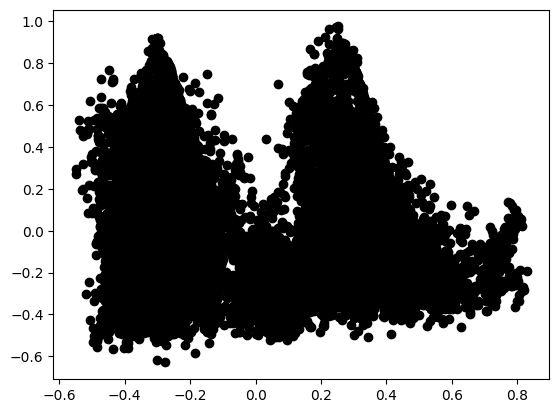

In [ ]:
import matplotlib.pyplot as plt

x = transformed[0]
y = transformed[1]

plt.scatter(x, y, color='black')
plt.show()

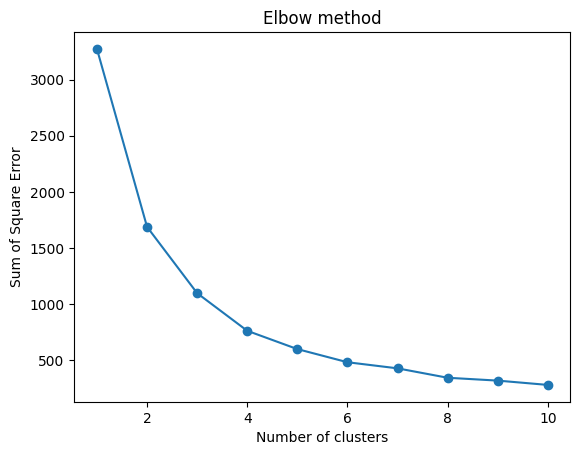

In [ ]:
from sklearn.cluster import KMeans

data = list(zip(x, y))
inertias = []

for i in range(1,11):
    kmeans = KMeans(n_clusters=i, n_init='auto')
    kmeans.fit(data)
    inertias.append(kmeans.inertia_)

plt.plot(range(1,11), inertias, marker='o')
plt.title('Elbow method')
plt.xlabel('Number of clusters')
plt.ylabel('Sum of Square Error')
plt.show()

Clear example of how we lose the quality of clustering as the elbow as become much smoother as compared to previous one.
Quality is good only if there is a steap downfall resulting in proper elbow shape.

In [ ]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=2, n_init='auto')
kmeans.fit(data)

c=kmeans.labels_
print(c)

[1 1 1 ... 1 1 1]


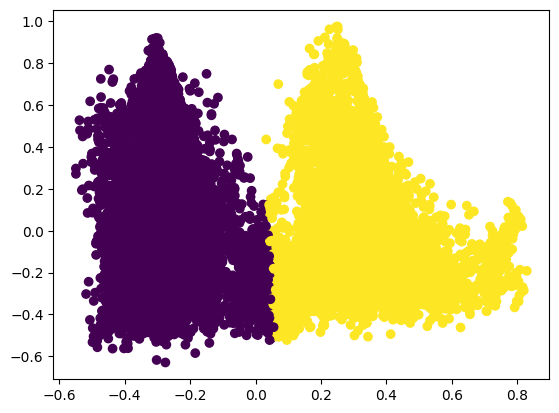

In [ ]:
plt.scatter(x, y, c=kmeans.labels_)
plt.show()

In [ ]:
from sklearn import metrics
metrics.silhouette_score(data, c, metric='euclidean')

0.48866457050243767

In [ ]:
metrics.calinski_harabasz_score(data, c)

19356.12619813933

In [ ]:
metrics.davies_bouldin_score(data, c)

0.860224291253695